In [1]:
import scanpy as sc
import os
import sys
import anndata as ad
import pandas as pd
import numpy as np
from plotnine import *
import cellhint
import seaborn as sns
import matplotlib.pyplot as plt



/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/umap/distances.py:1086: NumbaDeprecatio

# Load fibroblasts

In [2]:
# sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(14,14))


In [ ]:
PATH='/nfs/team298/ls34/fibroblast_atlas_paper/final_adatas_chloecolours/adata_lesional11.h5ad'
adata=sc.read_h5ad(PATH)
adata.X[:6,:6].A


In [2]:
adata=sc.read_h5ad('/nfs/team298/ls34/disease_atlas/final_fb_adatas/adata_all_6150_umap5.h5ad.paga2.annotated9.lesionalonly')
adata.X[:6,:6].A

#adata_5k.obs[x] 

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/nfs/team298/ls34/disease_atlas/final_fb_adatas/adata_all_6150_umap5.h5ad.paga2.annotated9.lesionalonly', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
#adata.write('/nfs/team361/inflow/')

In [ ]:
adata_5k=adata

In [ ]:
sc.settings.set_figure_params(dpi_save=300, dpi=300, facecolor="white", frameon=False, figsize=(5,5))# grid=False)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.grid'] = False


# Gene markers (melanoma SCP)

In [ ]:
GENES0 = ['COL5A1',
 'POSTN',
 'COL5A2',
 'THY1',
 'CTSK',
 'CXCL12',
 'AEBP1',
 'MRC2',
 'FSTL1',
 'CCDC80',
 'CTHRC1',
 'CDH11',
 'COL11A1',
 'THBS2',
 'ADAM12',
 'OLFML3',
 'FMOD',
 'MMP14',
 'HTRA1',
 'PRRX1',
 'PDGFRA',
 'PDPN',
 'THBS1',
 'COMP',
 'DPT',
 'CCN1',
 'LRRC15',
 'FBLN2',
 'PDGFRB',
 'ADAMTS2',
 'CCN5',
 'LOXL1',
 'IL6',
 'C1QTNF6',
 'SULF1',
 'SFRP4',
 'NBL1',
 'SMOC2',
 'IL1R1',
 'CA12',
 'EPAS1',
 'LOX',
 'TWIST2',
 'GJA1',
 'ANGPTL2',
 'APP',
 'SPON1',
 'CFB',
 'SOCS3',
 'ADAMTS1']
len(GENES0)

In [ ]:
CONTROL_SIZE = 1000 #
N_BINS=25  
adata = sc.tl.score_genes(adata, GENES0, ctrl_size=CONTROL_SIZE, n_bins=N_BINS, copy=True, score_name="Stroma_MCP")


In [ ]:

cluster_scores = adata.obs.groupby('Patient_status2')[['Stroma_MCP']].mean()

In [9]:

# def plot_matrix(cluster_scores, cmap="viridis", normalisation=None, colorbar_ticks=[0, 0.5, 1], dataset_name="Prenatal Fibroblasts",
#                reorder_dict=None, reorder_list=None, FIGSIZE=(10, 0.5)):
#     max_score = cluster_scores.max().max()
    
#     if reorder_list:
#         cluster_scores = cluster_scores.loc[reorder_list]
#     if reorder_dict:
#         cluster_scores.rename(columns=reorder_dict, inplace=True)
    
#     if not normalisation:
#         cluster_scores_normalized = cluster_scores
#     else:
#         if normalisation == "max":
#             cluster_scores_normalized = cluster_scores / max_score
#         elif normalisation == "minmax":
#             cluster_scores_normalized = (cluster_scores - cluster_scores.min()) / (cluster_scores.max() - cluster_scores.min())
#         elif normalisation == "row":
#             cluster_scores_normalized = cluster_scores.div(cluster_scores.max(axis=0), axis=1)
#         elif normalisation == "col":
#             cluster_scores_normalized = cluster_scores.div(cluster_scores.max(axis=1), axis=0)
#         else:
#             print("Not valid normalisation method. Choose from ['max', 'minmax', 'row', 'col']")
    
#     fig, ax = plt.subplots(figsize=FIGSIZE)
    
#     sns.heatmap(cluster_scores_normalized.T,  
#                 cmap=cmap,
#                 linewidths=0.01,
#                 cbar_kws={"label": "Gene module\nscore"},
#                 vmin=0,
#                 ax=ax)
    
#     cbar = ax.collections[0].colorbar
#     cbar.set_ticks(colorbar_ticks)
#     cbar.set_ticklabels(colorbar_ticks)
    
#     ax.set_xticks([i + 0.5 for i in range(len(cluster_scores_normalized.index))])
#     ax.set_xticklabels(cluster_scores_normalized.index, rotation=90, fontsize=12, ha='center')  
    
#     ax.set_yticks([])  

#     plt.title(normalisation, fontsize=14)  
#     plt.xlabel(dataset_name, fontsize=14)  
#     plt.ylabel("", fontsize=14)  

#     plt.tight_layout()  
#     plt.savefig("figures/gene_modules.pdf", dpi=300, bbox_inches="tight")  
#     plt.show()

# plot_matrix(cluster_scores, cmap="bwr", normalisation="minmax", colorbar_ticks=[0, 0.5, 1], FIGSIZE=(10, 0.5), dataset_name="")

maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
name pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 51 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'G', 'H', 'K', 'L', 'M', 'N', 'P', 'R', 'S', 'a', 'b', 'c', 'colon', 'd', 'e', 'f', 'five', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'q', 'quotesingle', 'r', 's', 'space', 't', 'u', 'v', 'x', 'y', 'z', 'zero']
Glyph IDs:   [0, 1, 2, 3, 10, 11, 12, 16, 17, 19, 20, 24, 29, 36, 37, 38, 39, 40, 42, 43, 46, 47, 48, 49, 51, 53, 54, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 93]
Closed glyph list over 'GSUB': 56 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'G', 'H', 'K', 'L', 'M', 'N', 'P', 'R', 'S', 'a', 'b', 'c', 'colon', 'd', 'e', 'f', 'fi', 'five', 'fl', 'g', 'h', 'hyph

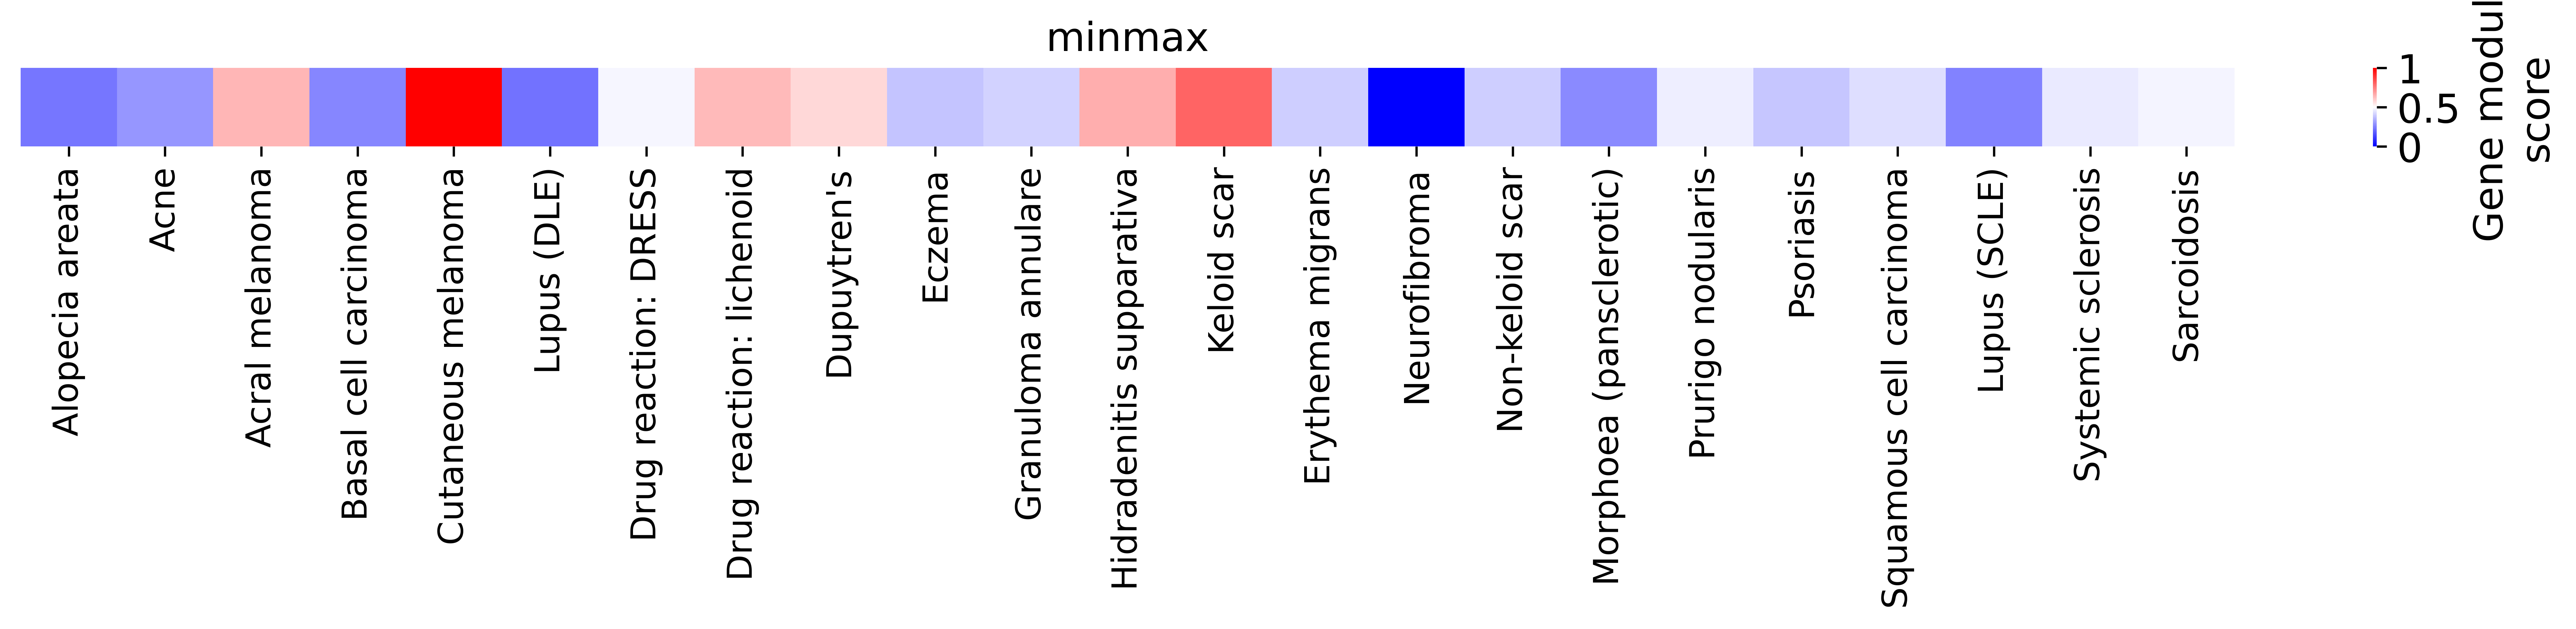

In [14]:
def plot_matrix(cluster_scores, cmap="viridis", normalisation=None, colorbar_ticks=[0, 0.5, 1], dataset_name="Prenatal Fibroblasts",
               reorder_dict=None, reorder_list=None, FIGSIZE=(20, 0.5)):
    max_score = cluster_scores.max().max()
    
    if reorder_list:
        cluster_scores = cluster_scores.loc[reorder_list]
    if reorder_dict:
        cluster_scores.rename(columns=reorder_dict, inplace=True)
    
    if not normalisation:
        cluster_scores_normalized = cluster_scores
    else:
        if normalisation == "max":
            cluster_scores_normalized = cluster_scores / max_score
        elif normalisation == "minmax":
            cluster_scores_normalized = (cluster_scores - cluster_scores.min()) / (cluster_scores.max() - cluster_scores.min())
        elif normalisation == "row":
            cluster_scores_normalized = cluster_scores.div(cluster_scores.max(axis=0), axis=1)
        elif normalisation == "col":
            cluster_scores_normalized = cluster_scores.div(cluster_scores.max(axis=1), axis=0)
        else:
            print("Not valid normalisation method. Choose from ['max', 'minmax', 'row', 'col']")
            return  # Exit on bad input
    
    fig, ax = plt.subplots(figsize=FIGSIZE)
    
    sns.heatmap(
        cluster_scores_normalized.T,
        cmap=cmap,
        linewidths=0,  # turn off the background grid
        cbar_kws={"label": "Gene module\nscore"},
        vmin=0,
        ax=ax
    )
    
    # Adjust colorbar ticks
    cbar = ax.collections[0].colorbar
    cbar.set_ticks(colorbar_ticks)
    cbar.set_ticklabels(colorbar_ticks)
    
    # Set ticks
    ax.set_xticks([i + 0.5 for i in range(len(cluster_scores_normalized.index))])
    ax.set_xticklabels(cluster_scores_normalized.index, rotation=90, fontsize=12, ha='center')
    ax.set_yticks([])

    # Labels
    plt.title(normalisation if normalisation else "", fontsize=14)
    plt.xlabel(dataset_name, fontsize=14)
    plt.ylabel("", fontsize=14)

    # Add some breathing room for the colorbar
    plt.subplots_adjust(right=0.85)  # shift plot left to make room on the right
    
    plt.savefig("figures/gene_modules.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
plot_matrix(cluster_scores, cmap="bwr", normalisation="minmax", colorbar_ticks=[0, 0.5, 1], FIGSIZE=(20, 0.5), dataset_name="")

In [11]:
STOP

NameError: name 'STOP' is not defined

In [ ]:
# plot_matrix(cluster_scores, cmap="minmax", normalisation=None, colorbar_ticks=[0, 0.5, 1],  FIGSIZE=(10, 0.5 ), dataset_name="")


In [ ]:
# plot_matrix(cluster_scores, cmap="seismic", normalisation="minmax", colorbar_ticks=[0, 0.5, 1], FIGSIZE=(10, 0.5), dataset_name="")

In [ ]:
# plot_matrix(cluster_scores, cmap="Reds", normalisation="minmax", colorbar_ticks=[0, 0.5, 1], FIGSIZE=(10, 0.5), dataset_name="")

In [ ]:
# plot_matrix(cluster_scores, cmap="Reds", normalisation="row", colorbar_ticks=[0, 0.5, 1],  FIGSIZE=(10, 0.5 ), dataset_name="")


In [ ]:
# plot_matrix(cluster_scores, cmap="bwr", normalisation="minmax", colorbar_ticks=[0, 0.5, 1], FIGSIZE=(10, 0.5), dataset_name="")


In [ ]:
def plot_matrix(cluster_scores, cmap="viridis", normalisation=None, colorbar_ticks=[0, 0.5, 1], dataset_name="Prenatal Fibroblasts",
               reorder_dict=None, reorder_list=None, FIGSIZE=(20, 0.5)):
    max_score = cluster_scores.max().max()
    
    if reorder_list:
        cluster_scores = cluster_scores.loc[reorder_list]
    if reorder_dict:
        cluster_scores.rename(columns=reorder_dict, inplace=True)
    
    if not normalisation:
        cluster_scores_normalized = cluster_scores
    else:
        if normalisation == "max":
            cluster_scores_normalized = cluster_scores / max_score
        elif normalisation == "minmax":
            cluster_scores_normalized = (cluster_scores - cluster_scores.min()) / (cluster_scores.max() - cluster_scores.min())
        elif normalisation == "row":
            cluster_scores_normalized = cluster_scores.div(cluster_scores.max(axis=0), axis=1)
        elif normalisation == "col":
            cluster_scores_normalized = cluster_scores.div(cluster_scores.max(axis=1), axis=0)
        else:
            print("Not valid normalisation method. Choose from ['max', 'minmax', 'row', 'col']")
            return  # Exit on bad input
    
    fig, ax = plt.subplots(figsize=FIGSIZE)
    
    sns.heatmap(
        cluster_scores_normalized.T,
        cmap=cmap,
        linewidths=0,  # turn off the background grid
        cbar_kws={"label": "Gene module\nscore"},
        vmin=0,
        ax=ax
    )
    
    # Adjust colorbar ticks
    cbar = ax.collections[0].colorbar
    cbar.set_ticks(colorbar_ticks)
    cbar.set_ticklabels(colorbar_ticks)
    
    # Set ticks
    ax.set_xticks([i + 0.5 for i in range(len(cluster_scores_normalized.index))])
    ax.set_xticklabels(cluster_scores_normalized.index, rotation=90, fontsize=12, ha='center')
    ax.set_yticks([])

    # Labels
    plt.title(normalisation if normalisation else "", fontsize=14)
    plt.xlabel(dataset_name, fontsize=14)
    plt.ylabel("", fontsize=14)

    # Add some breathing room for the colorbar
    plt.subplots_adjust(right=0.85)  # shift plot left to make room on the right
    
    plt.savefig("figures/gene_modules_v2.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
plot_matrix(cluster_scores, cmap="bwr", normalisation="minmax", colorbar_ticks=[0, 0.5, 1], FIGSIZE=(20, 0.5), dataset_name="")